# Intersectional Bias Analysis

Robustness and RERI-based intersectional analysis across IBM Granite, Llama, and Mistral.

In [35]:
import warnings
warnings.filterwarnings('ignore')

import textwrap
from pathlib import Path

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import blended_transform_factory
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

mpl.rcParams.update(mpl.rcParamsDefault)

In [36]:
DATA = Path('../data/output')

MODEL_NAMES = {
    'granite': 'IBM Granite 3.0-8B Instruct',
    'llama':   'Llama 3.1-8B',
    'mistral': 'Mistral 7B Instruct',
}
MODEL_COLORS = {
    'granite': '#2C6FBF',
    'llama':   '#C0392B',
    'mistral': '#27AE60',
}

ATTRS = ['Visibility', 'Persistent Course', 'Disrupt',
         'Unappealing Aesthetics', 'Controllable Origin', 'Peril']
SAFE  = {c: c.replace(' ', '_') for c in ATTRS}

terms_to_plot = ([f'mean_{s}' for s in SAFE.values()] +
                 [f'diff_{s}'  for s in SAFE.values()])
_mean_terms  = ' + '.join(f'mean_{s}' for s in SAFE.values())
_diff_terms  = ' + '.join(f'diff_{s}'  for s in SAFE.values())
formula_raw  = f'reri ~ {_mean_terms} + {_diff_terms}'
formula_adj  = f'reri ~ expected + {_mean_terms} + {_diff_terms}'

SUBSTANCE_CLUSTER = 'Unappealing Persistent'
RACE_CLUSTER      = 'Sociodemographic'

In [37]:
def load_model(path):
    d = pd.read_csv(path)
    d = d.drop(columns=['prompt'], errors='ignore')
    d['biased'] = (d['model_answer'] == d['biased_answer']).astype(int)
    return d[d['model_answer'].isin(['yes', 'no'])].copy()


def compute_excess(valid):
    """Return (baseline_rate, single_bias_series, intersectional_bias_df)"""
    baseline = valid[
        (valid['stigma2'].isna()) & (valid['prompt_style'] == 'base')
    ]['biased'].mean()

    single_grp  = (valid[(valid['stigma2'].isna()) & (valid['prompt_style'] != 'base')]
                   .groupby('stigma1')['biased'])
    single_bias = single_grp.mean().rename('single_bias_rate')
    single_n    = single_grp.count().rename('single_n')

    raw = (
        valid[(valid['stigma2'].notna()) & (valid['prompt_style'] != 'base')]
        .groupby(['stigma1', 'stigma2'])['biased']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'combined_bias_rate', 'count': 'n'})
    )
    raw['pair'] = raw.apply(lambda r: tuple(sorted([r['stigma1'], r['stigma2']])), axis=1)
    ib = raw.groupby('pair').agg(
        combined_bias_rate=('combined_bias_rate', 'mean'),
        n_AB=('n', 'sum')
    ).reset_index()
    ib[['stigma1', 'stigma2']] = pd.DataFrame(ib['pair'].tolist(), index=ib.index)
    ib = ib.drop(columns='pair')

    ib = ib.merge(single_bias.rename('bias_A'), left_on='stigma1', right_index=True, how='left')
    ib = ib.merge(single_n.rename('n_A'),       left_on='stigma1', right_index=True, how='left')
    ib = ib.merge(single_bias.rename('bias_B'), left_on='stigma2', right_index=True, how='left')
    ib = ib.merge(single_n.rename('n_B'),       left_on='stigma2', right_index=True, how='left')

    ib['expected_additive'] = ib['bias_A'] + ib['bias_B'] - baseline
    ib['excess']            = ib['combined_bias_rate'] - ib['expected_additive']
    return baseline, single_bias, ib


def build_features(ib, baseline, attr_lookup):
    """Merge stigma-pair RERI with attribute features for OLS"""
    df = ib.copy()
    df['reri']     = df['combined_bias_rate'] - df['bias_A'] - df['bias_B'] + baseline
    df['expected'] = df['bias_A'] + df['bias_B'] - baseline

    df = df.merge(attr_lookup.add_suffix('_A').rename(columns={'stigma_A': 'stigma1'}),
                  on='stigma1', how='left')
    df = df.merge(attr_lookup.add_suffix('_B').rename(columns={'stigma_B': 'stigma2'}),
                  on='stigma2', how='left')

    for col, safe in SAFE.items():
        df[f'mean_{safe}'] = (df[f'{col}_A'] + df[f'{col}_B']) / 2
        df[f'diff_{safe}'] = (df[f'{col}_A'] - df[f'{col}_B']).abs()

    keep = (['reri', 'expected'] +
            [f'mean_{s}' for s in SAFE.values()] +
            [f'diff_{s}'  for s in SAFE.values()])
    return df[keep].dropna()


def reri_ci(row, z=1.96):
    p_AB = row['combined_bias_rate']
    p_A  = row['bias_A']
    p_B  = row['bias_B']
    reri = row['reri']
    var  = (p_AB*(1-p_AB)/row['n_AB'] +
            p_A *(1-p_A) /row['n_A']  +
            p_B *(1-p_B) /row['n_B'])
    se = np.sqrt(var)
    return reri - z*se, reri + z*se


def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def wrap(text, width):
    lines = textwrap.wrap(str(text), width)
    return chr(10).join(lines)

## 1. Data Loading

In [38]:
# model response data
dfs = {}
for path in sorted(DATA.glob('results__*__with_single__*.csv')):
    d = load_model(path)
    model = d['model'].iloc[0]
    dfs[model] = d
    print(f'{model}: {len(d):,} rows')

# adding the atributes
_neo        = pd.read_csv(DATA.parent / 'templates' / 'neostigmas.csv')
cluster_map = _neo.set_index('Stigma')['Cluster'].str.replace(r'^\d+ - ', '', regex=True).to_dict()

_neo_idx = _neo.set_index('Stigma')
_neo_idx = _neo_idx[~_neo_idx.index.duplicated(keep='first')]
attr_df = pd.DataFrame(
    {col: pd.to_numeric(
             _neo_idx[col].astype(str).str.split('/').str[0].str.strip(),
             errors='coerce')
     for col in ATTRS}
).dropna(how='all')
attr_lookup = attr_df.reset_index().rename(columns={'Stigma': 'stigma'})

print(f"\nattr_df: {attr_df.shape[0]} stigmas × {attr_df.shape[1]} attributes")
print("NaN counts per column:", attr_df.isna().sum().to_dict())
print("\nSample (first 3 rows):")
print(attr_df.head(3).round(3))

granite: 1,837,598 rows
llama: 1,856,512 rows
mistral: 1,854,522 rows

attr_df: 112 stigmas × 6 attributes
NaN counts per column: {'Visibility': 0, 'Persistent Course': 0, 'Disrupt': 0, 'Unappealing Aesthetics': 0, 'Controllable Origin': 0, 'Peril': 0}

Sample (first 3 rows):
                                    Visibility  Persistent Course  Disrupt  \
Stigma                                                                       
Autism Or Autism Spectrum Disorder        3.68               5.09     4.38   
Bipolar Disorder Symptomatic              2.60               4.31     3.67   
Blind Completely                          4.97               5.39     3.39   

                                    Unappealing Aesthetics  \
Stigma                                                       
Autism Or Autism Spectrum Disorder                    2.41   
Bipolar Disorder Symptomatic                          2.23   
Blind Completely                                      1.42   

                     

In [39]:

for csv_path in sorted(DATA.glob('results__*__with_single__*.csv')):
    raw = pd.read_csv(csv_path)
    raw = raw.drop(columns=['prompt'], errors='ignore')
    model_name = raw['model'].iloc[0]

    total      = len(raw)
    yes_no     = raw['model_answer'].isin(['yes', 'no']).sum()
    non_yn     = total - yes_no
    non_yn_pct = 100 * non_yn / total

    non_yn_counts = (raw[~raw['model_answer'].isin(['yes', 'no'])]
                     ['model_answer'].value_counts())

    raw['biased'] = (raw['model_answer'] == raw['biased_answer']).astype(int)
    yn = raw[raw['model_answer'].isin(['yes', 'no'])]
    baseline_bias = (yn[(yn['stigma2'].isna()) & (yn['prompt_style'] == 'base')]
                     ['biased'].mean())
    single_bias   = (yn[(yn['stigma2'].isna()) & (yn['prompt_style'] != 'base')]
                     ['biased'].mean())

    print(f"\n{model_name}")
    print(f"  Total responses    : {total:>10,}")
    print(f"  Yes / No           : {yes_no:>10,}  ({100*yes_no/total:.1f}%)")
    print(f"  Non yes/no         : {non_yn:>10,}  ({non_yn_pct:.2f}%)")
    if len(non_yn_counts):
        for val, cnt in non_yn_counts.items():
            print(f"    └─ {val!r:25s}: {cnt:,}")
    print(f"  Baseline bias rate : {baseline_bias:.4f}  (base prompts, single stigma)")
    print(f"  Single-stigma bias : {single_bias:.4f}  (non-base prompts, single stigma)")

#######################################################
rudimentary model analysis
#######################################################

granite
  Total responses    :  1,856,512
  Yes / No           :  1,837,598  (99.0%)
  Non yes/no         :     18,914  (1.02%)
    └─ 'improper output'        : 18,914
  Baseline bias rate : 0.1460  (base prompts, single stigma)
  Single-stigma bias : 0.3159  (non-base prompts, single stigma)

llama
  Total responses    :  1,856,512
  Yes / No           :  1,856,512  (100.0%)
  Non yes/no         :          0  (0.00%)
  Baseline bias rate : 0.1125  (base prompts, single stigma)
  Single-stigma bias : 0.2557  (non-base prompts, single stigma)

mistral
  Total responses    :  1,854,528
  Yes / No           :  1,854,522  (100.0%)
  Non yes/no         :          6  (0.00%)
    └─ 'improper output'        : 6
  Baseline bias rate : 0.0856  (base prompts, single stigma)
  Single-stigma bias : 0.2997  (non-base prompts, single stigma)


## 2. RERI: Intersectional Bias Measurement

$$\text{Interaction Effect} = P(\text{bias} \mid A+B) - P(\text{bias} \mid A) - P(\text{bias} \mid B) + baseline$$

- **> 0**: intersection amplifies bias
- **< 0**: intersection dampens bias
- **= 0**: additive, no interaction

In [22]:
model_excess = {}
for model, v in dfs.items():
    baseline, single_bias, ib = compute_excess(v)
    model_excess[model] = {'baseline': baseline, 'single_bias': single_bias, 'ib': ib}
    print(f'{model}  baseline={baseline:.4f}  mean_excess={ib["excess"].mean():.4f}')

granite  baseline=0.1460  mean_excess=-0.0898
llama  baseline=0.1125  mean_excess=-0.0784
mistral  baseline=0.0856  mean_excess=-0.1298


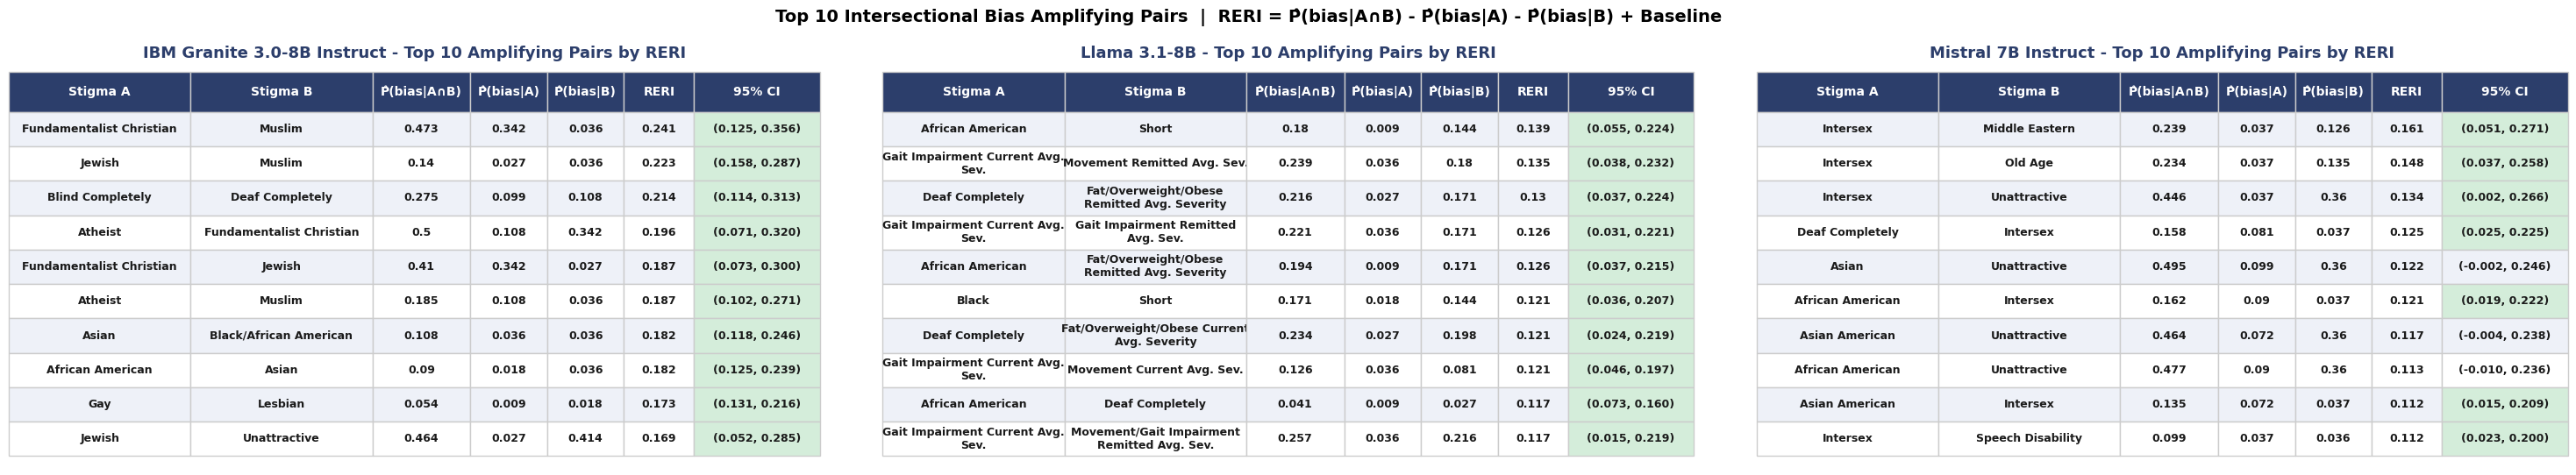

Saved top10_reri.png


In [23]:
models   = list(model_excess.keys())
n_models = len(models)

fig, axes = plt.subplots(1, n_models, figsize=(12 * n_models, 6), facecolor='white')
fig.subplots_adjust(wspace=0.25)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    ib = model_excess[model]['ib'].copy()
    baseline = model_excess[model]['baseline']
    ib['reri'] = ib['combined_bias_rate'] - ib['bias_A'] - ib['bias_B'] + baseline

    top = ib.nlargest(10, 'reri')[[
        'stigma1', 'stigma2', 'combined_bias_rate', 'bias_A', 'bias_B', 'reri',
        'n_AB', 'n_A', 'n_B'
    ]].reset_index(drop=True)

    ci_vals       = top.apply(reri_ci, axis=1, result_type='expand')
    top['ci_low']  = ci_vals[0]
    top['ci_high'] = ci_vals[1]
    top['95% CI']  = top.apply(lambda r: f"({r['ci_low']:.3f}, {r['ci_high']:.3f})", axis=1)

    display_cols = ['stigma1', 'stigma2', 'combined_bias_rate', 'bias_A', 'bias_B', 'reri', '95% CI']
    top_display  = top[display_cols].round({'combined_bias_rate': 3, 'bias_A': 3, 'bias_B': 3, 'reri': 3})

    col_labels  = ['Stigma A', 'Stigma B', 'P̂(bias|A∩B)', 'P̂(bias|A)', 'P̂(bias|B)', 'RERI', '95% CI']
    col_widths  = [0.26, 0.26, 0.14, 0.11, 0.11, 0.10, 0.18]
    wrap_widths = [28, 28, 12, 9, 9, 8, 18]

    cell_data = [
        [wrap(str(row[c]), w) for c, w in zip(top_display.columns, wrap_widths)]
        for _, row in top_display.iterrows()
    ]

    header_color = '#2C3E6B'
    row_colors   = ['#EEF1F8', '#FFFFFF']
    ci_col_index = col_labels.index('95% CI')

    ax.axis('off')
    table = ax.table(
        cellText=cell_data,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
        colWidths=col_widths,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.PAD = 0.03
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold', fontsize=10)
            cell.set_height(0.10)
        else:
            base_color = row_colors[(row - 1) % 2]
            if col == ci_col_index:
                lo = top.iloc[row - 1]['ci_low']
                hi = top.iloc[row - 1]['ci_high']
                if lo > 0:
                    cell.set_facecolor('#d4edda')
                elif hi < 0:
                    cell.set_facecolor('#f8d7da')
                else:
                    cell.set_facecolor(base_color)
            else:
                cell.set_facecolor(base_color)
            cell.set_text_props(color='#1a1a1a', fontweight='semibold', fontsize=9)
            cell.set_height(0.085)

    ax.set_title(f'{MODEL_NAMES.get(model, model.capitalize())} - Top 10 Amplifying Pairs by RERI',
                 fontsize=13, fontweight='bold', color='#2C3E6B', pad=2)

plt.suptitle('Top 10 Intersectional Bias Amplifying Pairs  |  RERI = P̂(bias|A∩B) - P̂(bias|A) - P̂(bias|B) + Baseline',
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig(DATA / 'top10_reri.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved top10_reri.png')

## 3. Cluster-Level Heatmap

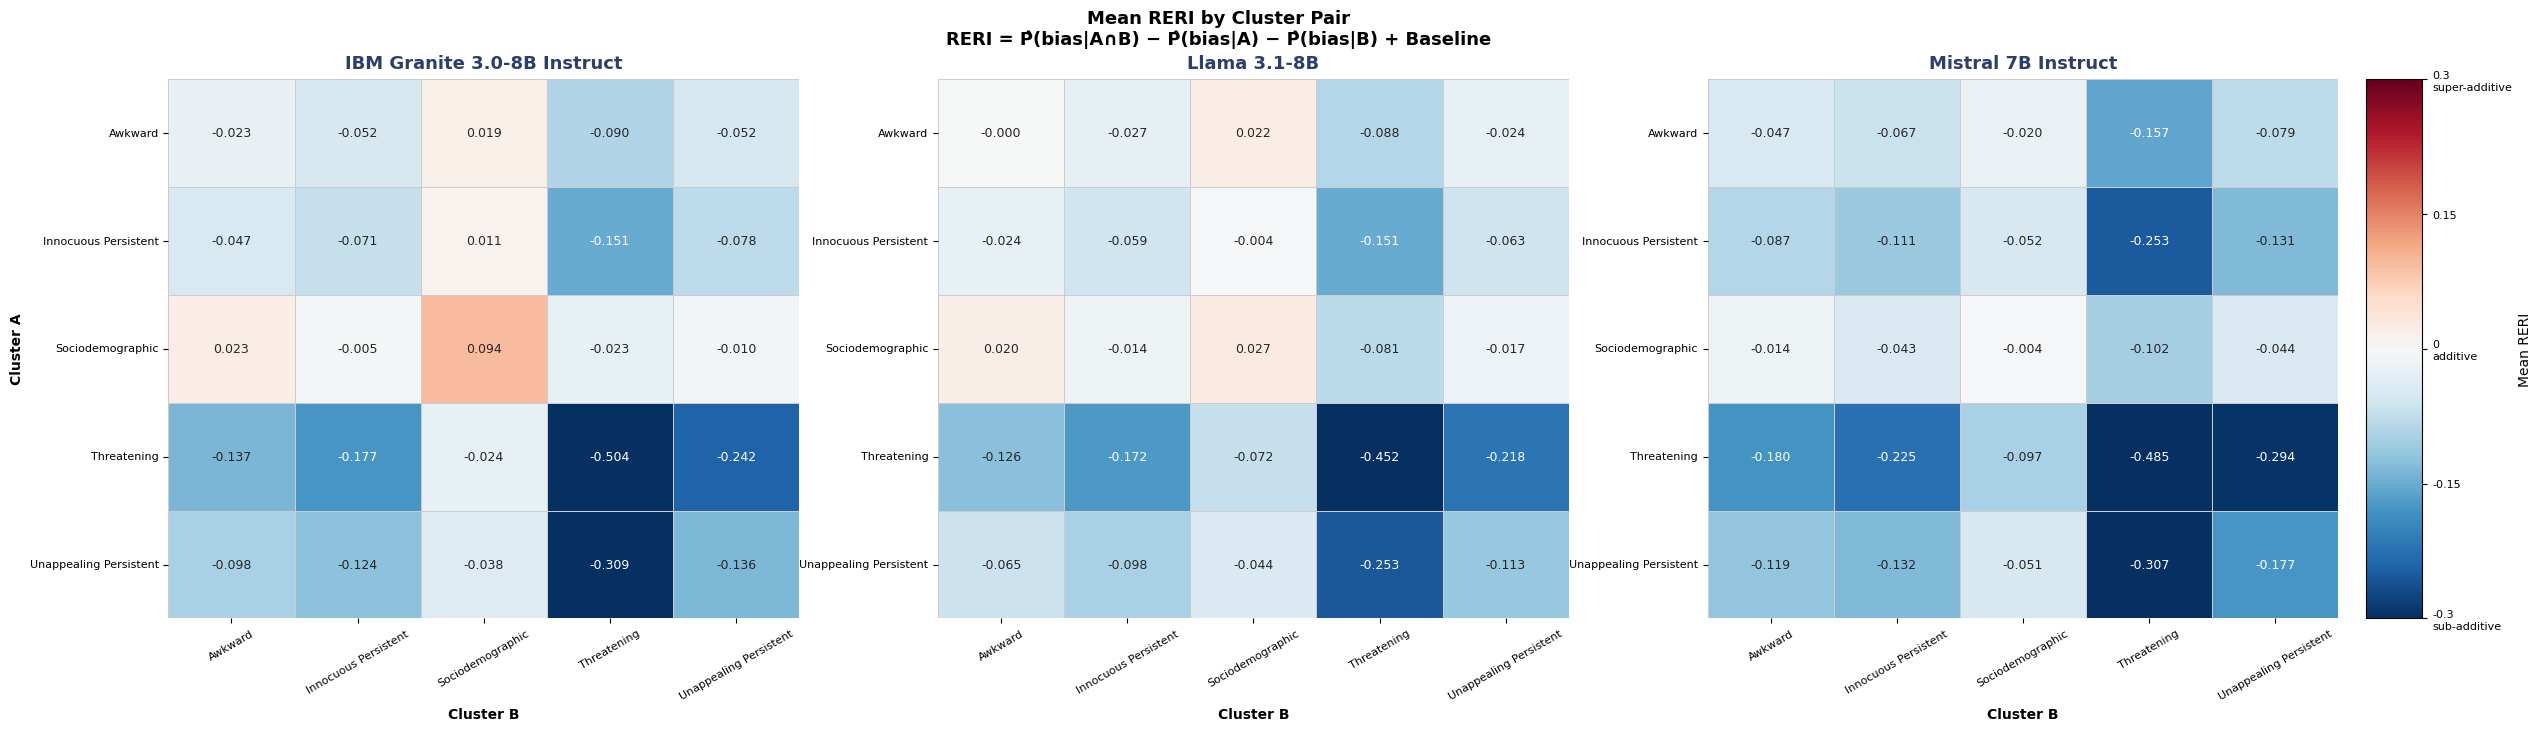

Saved heatmap_clusters_sidebyside.png


In [24]:
norm = mcolors.TwoSlopeNorm(vmin=-0.3, vcenter=0, vmax=0.3)

fig, axes = plt.subplots(1, len(model_excess), figsize=(9 * len(model_excess) + 1, 7), facecolor='white')
fig.subplots_adjust(wspace=0.22)
axes_list = [axes] if len(model_excess) == 1 else list(axes)

for ax, model in zip(axes_list, model_excess):
    ib = model_excess[model]['ib'].copy()
    baseline = model_excess[model]['baseline']
    ib['reri']      = ib['combined_bias_rate'] - ib['bias_A'] - ib['bias_B'] + baseline
    ib['cluster_A'] = ib['stigma1'].map(cluster_map)
    ib['cluster_B'] = ib['stigma2'].map(cluster_map)

    pivot  = ib.groupby(['cluster_A', 'cluster_B'])['reri'].mean().reset_index()
    matrix = pivot.pivot(index='cluster_A', columns='cluster_B', values='reri')
    matrix = matrix.reindex(index=matrix.columns)
    matrix.index.name   = None
    matrix.columns.name = None

    sns.heatmap(
        matrix, ax=ax, cmap='RdBu_r', norm=norm,
        annot=True, fmt='.3f', annot_kws={'size': 9},
        linewidths=0.5, linecolor='#cccccc',
        cbar=False, xticklabels=True, yticklabels=True
    )
    ax.set_title(MODEL_NAMES.get(model, model.capitalize()),
                 fontsize=13, fontweight='bold', color='#2C3E6B', pad=8)
    ax.set_xlabel('Cluster B', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cluster A' if ax is axes_list[0] else '', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

fig.canvas.draw()
pos = axes_list[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])
sm  = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([-0.3, -0.15, 0, 0.15, 0.3])
cbar.set_ticklabels(['-0.3\nsub-additive', '-0.15', '0\nadditive', '0.15', '0.3\nsuper-additive'])
cbar.set_label('Mean RERI', fontsize=10)
cbar.ax.tick_params(labelsize=8)

plt.suptitle('Mean RERI by Cluster Pair\nRERI = P̂(bias|A∩B) − P̂(bias|A) − P̂(bias|B) + Baseline',
             fontsize=13, fontweight='bold', y=0.98)
plt.savefig(DATA / 'heatmap_clusters_sidebyside.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved heatmap_clusters_sidebyside.png')

In [25]:
matrices = {}
for model in model_excess:
    ib = model_excess[model]['ib'].copy()
    baseline = model_excess[model]['baseline']
    ib['reri']      = ib['combined_bias_rate'] - ib['bias_A'] - ib['bias_B'] + baseline
    ib['cluster_A'] = ib['stigma1'].map(cluster_map)
    ib['cluster_B'] = ib['stigma2'].map(cluster_map)
    pivot  = ib.groupby(['cluster_A', 'cluster_B'])['reri'].mean().reset_index()
    matrix = pivot.pivot(index='cluster_A', columns='cluster_B', values='reri')
    matrix = matrix.reindex(index=matrix.columns)
    matrices[model] = matrix

ref          = list(matrices.values())[0]
pair_labels  = [f"{r} × {c}" for r in ref.index for c in ref.columns]
model_names  = list(matrices.keys())
reri_vectors = np.array([matrices[m].values.flatten() for m in matrices])

# Kendall's W
k, n  = reri_vectors.shape
ranks = np.array([stats.rankdata(v) for v in reri_vectors])
R     = ranks.sum(axis=0)
S     = np.sum((R - R.mean()) ** 2)
W     = 12 * S / (k**2 * (n**3 - n))
chi2_stat = k * (n - 1) * W
p_val     = stats.chi2.sf(chi2_stat, df=n - 1)

interp = ("very strong" if W >= 0.9 else "strong" if W >= 0.7
          else "moderate" if W >= 0.5 else "weak")

print(f"Kendall's W — concordance across {k} models on {n} cluster pairs")
print(f"  W  = {W:.4f}  ({interp} agreement)")
print(f"  χ² = {chi2_stat:.3f},  df = {n-1},  p = {p_val:.4e}")

rank_df = (pd.DataFrame({'Cluster Pair': pair_labels, 'Rank Sum': R})
             .sort_values('Rank Sum', ascending=False)
             .reset_index(drop=True))
rank_df.index += 1
print("\nMost consistently amplifying (highest rank sum):")
print(rank_df.head(5).to_string())
print("\nMost consistently dampening (lowest rank sum):")
print(rank_df.tail(5).sort_values('Rank Sum').to_string())

Kendall's W — concordance across 3 models on 25 cluster pairs
  W  = 0.9708  (very strong agreement)
  χ² = 69.895,  df = 24,  p = 2.2677e-06

Most consistently amplifying (highest rank sum):
                              Cluster Pair  Rank Sum
1      Sociodemographic × Sociodemographic      75.0
2               Sociodemographic × Awkward      71.0
3               Awkward × Sociodemographic      70.0
4  Sociodemographic × Innocuous Persistent      63.0
5  Innocuous Persistent × Sociodemographic      61.0

Most consistently dampening (lowest rank sum):
                            Cluster Pair  Rank Sum
25             Threatening × Threatening       3.0
24  Unappealing Persistent × Threatening       6.0
23  Threatening × Unappealing Persistent       9.0
22    Threatening × Innocuous Persistent      13.0
21    Innocuous Persistent × Threatening      14.0


In [34]:
# Pairwise Spearman correlations
n_m     = len(model_names)


# Cosine similarity
cos_mat = np.ones((n_m, n_m))
for i in range(n_m):
    for j in range(n_m):
        if i != j:
            cos_mat[i, j] = cosine_sim(reri_vectors[i], reri_vectors[j])
cos_df = pd.DataFrame(cos_mat, index=model_names, columns=model_names).round(4)
print("\nCosine Similarity (raw RERI vectors)")
print(cos_df.to_string())

print("\nMean RERI per model (magnitude check):")
for model, vec in zip(model_names, reri_vectors):
    print(f"  {model:10s}  mean={vec.mean():.4f}  min={vec.min():.4f}  max={vec.max():.4f}")


Cosine Similarity (raw RERI vectors)
         granite   llama  mistral
granite   1.0000  0.9849   0.9594
llama     0.9849  1.0000   0.9734
mistral   0.9594  0.9734   1.0000

Mean RERI per model (magnitude check):
  granite     mean=-0.0897  min=-0.5036  max=0.0943
  llama       mean=-0.0839  min=-0.4516  max=0.0266
  mistral     mean=-0.1311  min=-0.4854  max=-0.0042


## 4. Plots

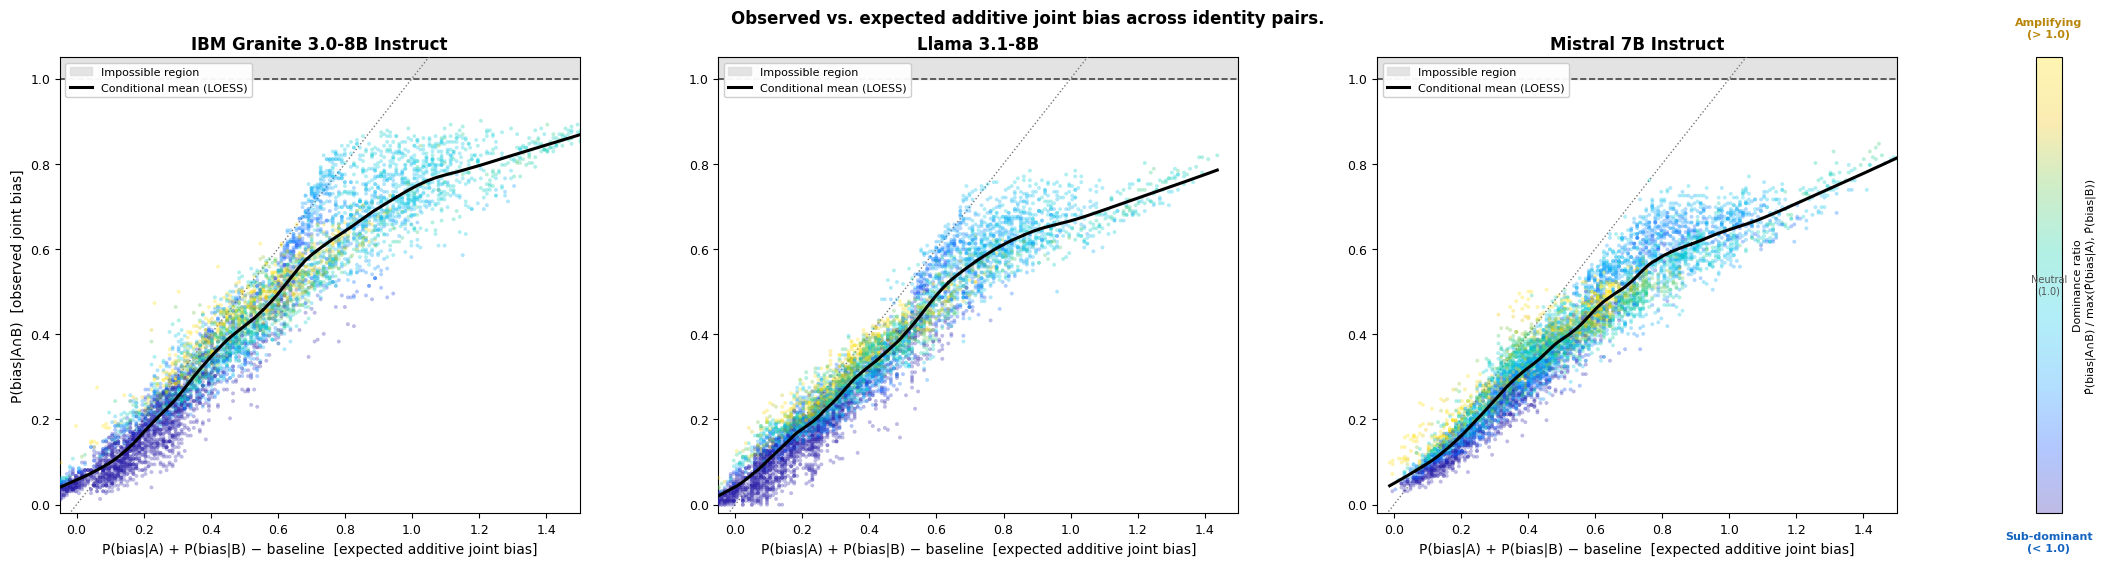

Saved impossible_region_mean.png


In [32]:
_parula_colors = ['#2A1FA8', '#0047FF', '#0099FF', '#00C8E8',
                  '#00CFA8', '#5EC44A', '#F0C000', '#FFE000'] # too lazy to seaborns, ada color pallet
cmap_parula  = LinearSegmentedColormap.from_list('parula', _parula_colors)
scatter_norm = mcolors.TwoSlopeNorm(vmin=0.7, vcenter=1.0, vmax=1.3)

n_m  = len(model_excess)
fig  = plt.figure(figsize=(7 * n_m + 1, 6), facecolor='white')
gs   = gridspec.GridSpec(1, n_m + 1, width_ratios=[*([7] * n_m), 0.35],
                         wspace=0.35, left=0.06, right=0.97, bottom=0.14, top=0.90)
axes = [fig.add_subplot(gs[0, i]) for i in range(n_m)]
cax  = fig.add_subplot(gs[0, n_m])

sc_last = None
for ax, (model, s) in zip(axes, model_excess.items()):
    ib  = s['ib'].dropna(subset=['bias_A', 'bias_B', 'combined_bias_rate']).copy()
    bv  = s['baseline']
    ib['x']         = ib['bias_A'] + ib['bias_B'] - bv
    ib['y']         = ib['combined_bias_rate']
    ib['dominance'] = (ib['y'] / ib[['bias_A', 'bias_B']].max(axis=1)).clip(0.7, 1.3)

    x_fill = np.linspace(-0.05, 1.5, 500)
    ax.fill_between(x_fill, 1.0, 1.05, color='#DDDDDD', alpha=0.8, zorder=0, label='Impossible region')
    ax.axhline(1.0, color='#444444', linewidth=1.2, linestyle='--', zorder=2)
    ax.plot([-0.05, 1.5], [-0.05, 1.5], color='#777777', linewidth=1.0, linestyle=':', zorder=3)

    sc = ax.scatter(ib['x'], ib['y'], c=ib['dominance'], cmap=cmap_parula, norm=scatter_norm,
                    alpha=0.30, s=8, linewidths=0, zorder=3)
    sc_last = sc

    smooth = lowess(ib['y'].values, ib['x'].values, frac=0.15, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], color='black', linewidth=2.2, zorder=5,
            label='Conditional mean (LOESS)')

    ax.set_xlabel('P(bias|A) + P(bias|B) − baseline  [expected additive joint bias]', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('P(bias|A∩B)  [observed joint bias]', fontsize=10)
    ax.set_title(MODEL_NAMES.get(model, model.capitalize()), fontsize=12, fontweight='bold', pad=6)
    ax.set_xlim(-0.05, 1.5)
    ax.set_ylim(-0.02, 1.05)
    ax.tick_params(labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color('black')
    ax.legend(fontsize=8, loc='upper left', framealpha=0.95)
    ax.set_facecolor('white')

cbar = fig.colorbar(sc_last, cax=cax)
cbar.set_ticks([])
cbar.set_label('Dominance ratio\nP̂(bias|A∩B) / max(P̂(bias|A), P̂(bias|B))', fontsize=8, labelpad=8)
cbar.ax.axhline(0.5, color='black', linewidth=1.0, linestyle='--')
cbar.ax.text(0.5, 1.04, 'Amplifying\n(> 1.0)', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='#B8860B', transform=cbar.ax.transAxes)
cbar.ax.text(0.5, 0.5,  'Neutral\n(1.0)',     ha='center', va='center',
             fontsize=7, color='#555555',  transform=cbar.ax.transAxes)
cbar.ax.text(0.5, -0.04, 'Sub-dominant\n(< 1.0)', ha='center', va='top',
             fontsize=8, fontweight='bold', color='#1565C0', transform=cbar.ax.transAxes)

plt.suptitle('Observed vs. expected additive joint bias across identity pairs.',
             fontsize=12, fontweight='bold', y=0.98)
plt.savefig(DATA / 'impossible_region_mean.png', dpi=150, facecolor='white')
plt.show()
print('Saved impossible_region_mean.png')

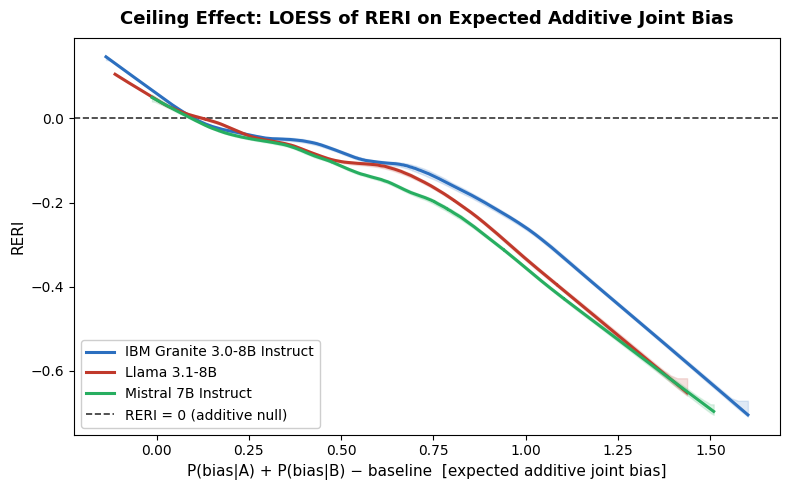

Saved ceiling_effect_loess.png


In [29]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

for model, s in model_excess.items():
    ib = s['ib'].dropna(subset=['bias_A', 'bias_B', 'combined_bias_rate']).copy()
    bv = s['baseline']
    ib['expected'] = ib['bias_A'] + ib['bias_B'] - bv
    ib['reri']     = ib['combined_bias_rate'] - ib['expected']

    x, y  = ib['expected'].values, ib['reri'].values
    color = MODEL_COLORS.get(model, '#555555')

    smoothed = lowess(y, x, frac=0.2, return_sorted=True)
    sx, sy   = smoothed[:, 0], smoothed[:, 1]

    rng = np.random.default_rng(42)
    boot_curves = []
    for _ in range(200):
        idx = rng.integers(0, len(x), size=len(x))
        bs  = lowess(y[idx], x[idx], frac=0.2, return_sorted=True)
        boot_curves.append(np.interp(sx, bs[:, 0], bs[:, 1]))

    ci_lo = np.percentile(boot_curves, 2.5,  axis=0)
    ci_hi = np.percentile(boot_curves, 97.5, axis=0)

    ax.plot(sx, sy, linewidth=2.2, color=color, label=MODEL_NAMES.get(model, model), zorder=3)
    ax.fill_between(sx, ci_lo, ci_hi, color=color, alpha=0.15, zorder=2)

ax.axhline(0, color='#333333', linewidth=1.2, linestyle='--', zorder=1,
           label='RERI = 0 (additive null)')
ax.set_xlabel('P(bias|A) + P(bias|B) − baseline  [expected additive joint bias]', fontsize=11)
ax.set_ylabel('RERI', fontsize=11)
ax.set_title('Ceiling Effect: LOESS of RERI on Expected Additive Joint Bias',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10, framealpha=0.95)
ax.tick_params(labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color('black')
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(DATA / 'ceiling_effect_loess.png', dpi=150, facecolor='white')
plt.show()
print('Saved ceiling_effect_loess.png')

## 6. Order Sensitivity

In [33]:
print("Order Sensitivity of Stigma Pairs")
print("#" * 55)

for csv_path in sorted(DATA.glob('results__*__with_single__*.csv')):
    raw = pd.read_csv(csv_path)
    raw['biased']   = (raw['model_answer'] == raw['biased_answer']).astype(int)
    model_name      = raw['model'].iloc[0]

    pairs = raw[
        raw['stigma2'].notna() &
        (raw['prompt_style'] != 'base') &
        raw['model_answer'].isin(['yes', 'no'])
    ]

    bias            = pairs.groupby(['stigma1', 'stigma2'])['biased'].mean().reset_index()
    bias.columns    = ['stigma1', 'stigma2', 'bias_rate']
    forward         = bias.copy()
    reverse         = bias.rename(columns={'stigma1': 'stigma2', 'stigma2': 'stigma1',
                                           'bias_rate': 'bias_rate_rev'})
    merged          = forward.merge(reverse, on=['stigma1', 'stigma2'])
    merged['diff']      = merged['bias_rate'] - merged['bias_rate_rev']
    merged['abs_diff']  = merged['diff'].abs()

    t, p = stats.ttest_rel(merged['bias_rate'], merged['bias_rate_rev'])
    r    = merged['bias_rate'].corr(merged['bias_rate_rev'])

    print(f"\n{model_name}  ({len(merged):,} ordered pairs)")
    print(f"  Mean |diff|   : {merged['abs_diff'].mean():.4f}")
    print(f"  Max  |diff|   : {merged['abs_diff'].max():.4f}")
    print(f"  Correlation r : {r:.4f}")
    print(f"  Paired t-test : t={t:.3f}, p={p:.4f}")

    top = (merged.nlargest(5, 'abs_diff')
           [['stigma1', 'stigma2', 'bias_rate', 'bias_rate_rev', 'diff']]
           .rename(columns={'bias_rate': 'bias(A,B)', 'bias_rate_rev': 'bias(B,A)'}))
    print("  Most order-sensitive pairs:")
    print(top.to_string(index=False))


Order Sensitivity of Stigma Pairs
#######################################################

granite  (12,432 ordered pairs)
  Mean |diff|   : 0.0489
  Max  |diff|   : 0.3243
  Correlation r : 0.9624
  Paired t-test : t=-0.000, p=1.0000
  Most order-sensitive pairs:
                    stigma1                     stigma2  bias(A,B)  bias(B,A)      diff
Alcohol Dependency Remitted                 South Asian   0.306306   0.630631 -0.324324
                South Asian Alcohol Dependency Remitted   0.630631   0.306306  0.324324
   Drug Dependency Remitted                 South Asian   0.342342   0.666667 -0.324324
                South Asian    Drug Dependency Remitted   0.666667   0.342342  0.324324
   Drug Dependency Remitted                      Latina   0.270270   0.576577 -0.306306

llama  (12,432 ordered pairs)
  Mean |diff|   : 0.0302
  Max  |diff|   : 0.2613
  Correlation r : 0.9792
  Paired t-test : t=-0.000, p=1.0000
  Most order-sensitive pairs:
                                  